<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# TS2: Modelizando un ADC
#### Sofía Makkos


#### Introducción

Durante el presente trabajo, se utilizará  la suma $S_n$ una señal senoidal contaminada con una función normal aleatoria, y se las digitalizará con un nivel predeterminado de ruido, es decir, mediante los bits definidos. Tanto el voltaje de cuantización *q* (definido por los bits) y y el factor de escala $k_n$, establecerán la relación entre entre las potencias de ruido $P_n$ y de ruido de cuantización $P_q$

\begin{equation}
P_q=\frac{q^2}{12} \wedge P_n=k_n*P_q
\end{equation}

A partir de este $P_n$ se obtendrá la distribución normal (mediante *np.random.normal*). Luego se compararán ilustrativamente el ruido analógico (de la distribución normal implementada), la suma $S_n$ cuantizada y el ruido de cuantización  $n_q$, este siendo la diferencia entre $S_n$ cuantizada y sin cuantizar. 


#### Desarrollo

In [1]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

In [2]:
fs=1000
N=1000

def mi_funcion_sen( vmax = np.sqrt(2), dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    tt=np.arange(0.0, N/fs, 1/fs)
    xx=vmax*np.sin(2*np.pi*ff*tt +ph)+dc
    return(tt, xx)

In [3]:
tt, xx= mi_funcion_sen(vmax = np.sqrt(2),ff=fs/N)

bits = 4
k= 1
Vfs = 2
q = (2*Vfs)/(np.pow(2,bits))
P_q = q**2/12
P_n = k* P_q
sigma = np.sqrt(P_n)
norm = np.random.normal(scale=sigma,size=len(tt))

sn = xx + norm
sn_cuantizada = np.round(sn/q)*q

Creo mi función sinusoidal *xx* y mi ruido con distribución normal *norm*. En esta primera parte, se utilizará $k_n$=1 y bits B=4. El voltaje de cuantización se describirá como $q=\frac{2*Vfs}{2^{B}}$. La potencia de la normal dependerá de estos valores.

Con la función *np.round* buscamos que nuestra nueva señal cuantizada *sn_cuantizada* tome valores de acuerdo con *q* aproximando mediante redondeo los valores de *sn* con respecto a *q*. Al multiplicar por *q*, se vuelve a la escala original de la señal *sn*.

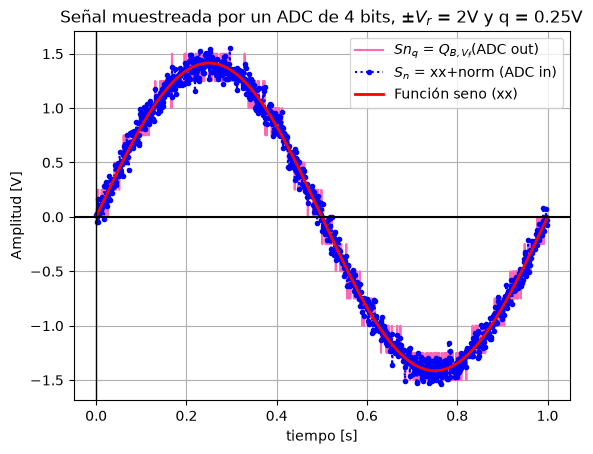

In [4]:
plt.figure(1)
plt.plot(tt,sn_cuantizada,color = "hotpink",label="$Sn_q$ = $Q_{B,V_f}$(ADC out)")
plt.plot(tt,sn, ":.", color = "blue",label="$S_n$ = xx+norm (ADC in)")
plt.plot(tt, xx, linestyle="-", linewidth=2, color="red", label="Función seno (xx)")
plt.title(f"Señal muestreada por un ADC de {bits} bits, ±$V_r$ = {Vfs}V y q = {q}V")
plt.xlabel("tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)
plt.legend()

Con esta figura, podemos ver cómo a la función seno se le suma el ruido (linea punteada azul), siguiendo el comportamiendo común de la senoidal (línea roja). Si se observa con detalle, veremos cómo la señal cuantizada *sn_cuantizada* (línea rosa) aparenta ser bastante similar a la sin cuantizar, aunque tome valores que discrepen de los originales. Esta diferenciación se distingue debido a los bits utilizados, en este caso, 4. La aproximación realizada mediante la cuantización será menos precisa.

In [5]:
def funcion_fft (xx):
    fftxx = fft(xx)
    fftxx = fftxx[:N//2]
    freq = fftfreq(N,1/fs)
    freq = freq[:N//2]
    fftxx_abs = np.abs(fftxx)
    return fftxx_abs, freq

# FFT y potencia de referencia de la suma del seno y la normal
fftsn_abs, freq=funcion_fft(sn)
ref = np.max(fftsn_abs)

# FFT y normalización de la suma cuantizada
fftsn_cuant_abs, freq=funcion_fft(sn_cuantizada)
sn_cuant_fft_dB = 20 * np.log10(fftsn_cuant_abs/ref)

# FFT y normalización de la normal
fftnorm_abs, freq=funcion_fft(norm)
norm_fft_dB = 20 * np.log10(fftnorm_abs/ref)

# FFT y normalización del ruido de cuantización
n_q = sn_cuantizada - sn
fftn_q_abs, freq=funcion_fft(n_q)
n_q_fft_dB = 20 * np.log10(fftn_q_abs/ref)

Aquí, se le aplicó FFT primero a la señal *Sn*, para tomar el valor de referencia de su potencia máxima. Luego, se utilizó la misma función para *Sn_cuantizada*, el ruido de distribución normal *norm* y el ruido de cuantización *n_q*. En cuanto a su normalización, se les empleó la potencia de referencia del *sn*, para convertirlos en densidades de potencia en decibeles.

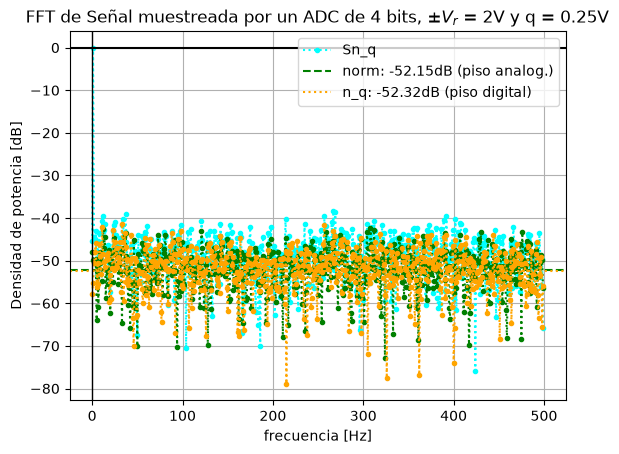

In [6]:
plt.figure(2)
plt.plot(freq,sn_cuant_fft_dB,":.", color="cyan",label="Sn_q")
plt.plot(freq,norm_fft_dB,":.", color="green")
plt.axhline(np.mean(norm_fft_dB), color="green", linestyle="--", label=f"norm: {np.mean(norm_fft_dB):.2f}dB (piso analog.)")
plt.plot(freq,n_q_fft_dB,":.", color="orange")
plt.axhline(np.mean(n_q_fft_dB), color="orange", linestyle=':', label=f"n_q: {np.mean(n_q_fft_dB):.2f}dB (piso digital)")
plt.legend()
plt.title(f"FFT de Señal muestreada por un ADC de {bits} bits, ±$V_r$ = {Vfs}V y q = {q}V")
plt.ylabel("Densidad de potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

Al graficar nuestras funciones en la misma figura, podemos relacionar sus comportamientos. 

En primer lugar, es difícil notar que en frecuencia cercana al eje y se encuentra el máximo valor de potencia de *sn_cuant_fft_dB*. Este es a causa del comportamiento de la sinusoidal involucrada en *Sn_q*, por el delta que se genera luego de aplicar la FFT.  

Luego, los pisos analógico y digital se solapan casi perfectamente, debido al factor de escala elegido, $k_n$=1. Así, las potencias de entrada y de salida del ADC son las mismas. Es notorio que muchos de los puntos entre la función del ruido de la normal *norm_fft_dB* y el ruido cuantizado *n_q_fft_dB* difieren bastante, sin embargo, al utilizar la función *np.mean*, conseguimos la potencia media de ambas (*norm* y *n_q* en el gráfico).

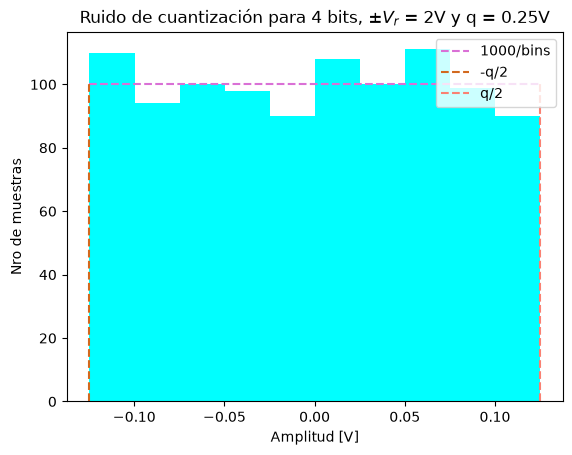

In [7]:
plt.figure (3)
plt.hist(n_q, color="cyan")
plt.hlines(100, xmin=-q/2, xmax=q/2,color="orchid", linestyle="--", label=f"{N}/bins")
plt.vlines(-q/2, ymin=0, ymax=100, color="chocolate", linestyle="--", label="-q/2")
plt.vlines(q/2,ymin=0, ymax=100, color="salmon", linestyle="--", label="q/2")
plt.title(f"Ruido de cuantización para {bits} bits, ±$V_r$ = {Vfs}V y q = {q}V")
plt.legend()
plt.xlabel("Amplitud [V]")
plt.ylabel("Nro de muestras")

plt.show()

En este histograma se representan la cantidad de muestras existentes para cada sección de $\frac{q}{2}$. Los límites laterales se tratan de $\pm\frac{q}{2}$, ya que son la máxima y mínima amplitud que puede adoptar el ruido de cuantización. El límite superior indicado se define a través de la cantidad de muestras del sistema, N=1000, y los bins de la función *plt.hist*, cuyo valor default es 10. Esto último también determina la cantidad de intervalos en que el gráfico de divide con respecto a la amplitud.

El histograma da a entender que los valores redondeados anteriormente se encuentran distribuidos equitativamente, o uniformemente, a lo largo de las muestras realizadas.

Ahora, prosigo a realizar el mismo procedimiento pero con dos cambios; $k_n$ ahora valdrá $\frac{1}{10}$ y tendrá 16 bits

In [8]:
tt, xx= mi_funcion_sen(vmax = np.sqrt(2),ff=fs/N)

bits = 16
k= 1/10
q = (2*Vfs)/(np.pow(2,bits))
P_q2 = q**2/12
P_n = k* P_q2
sigma = np.sqrt(P_n)
norm = np.random.normal(scale=sigma,size=len(tt))

sn = xx + norm
sn_cuantizada = np.round(sn/q)*q

Con estos nuevos valores, habrán grandes cambios. Primero, el voltaje de cuantización será mucho menor que antes, debido a la potencia de los bits en el denominador.

In [9]:
print(q)

6.103515625e-05


Luego, la potencia del ruido de cuantización también se verá modificada:

In [10]:
print(P_q, P_q2)

0.005208333333333333 3.104408582051595e-10


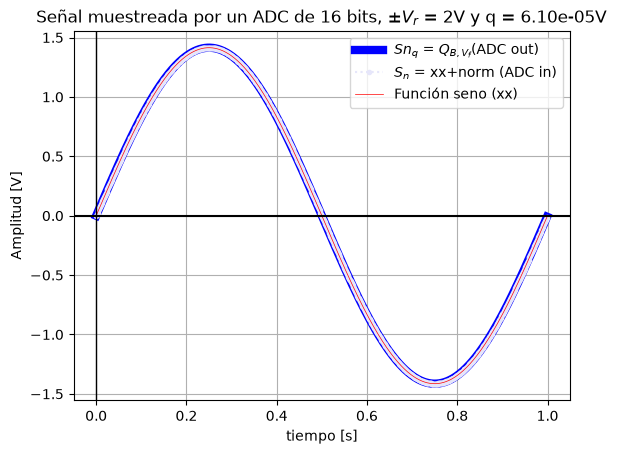

In [11]:
plt.figure(4)
plt.plot(tt,sn_cuantizada,color = "blue",linewidth=6,label="$Sn_q$ = $Q_{B,V_f}$(ADC out)")
plt.plot(tt,sn, ":.", color = "lavender",label="$S_n$ = xx+norm (ADC in)")
plt.plot(tt, xx, linestyle="-", linewidth=0.5, color="red", label="Función seno (xx)")
plt.title(f"Señal muestreada por un ADC de {bits} bits, ±$V_r$ = {Vfs}V y q = {q:.2e}V")
plt.xlabel("tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)
plt.legend()

En este último gráfico, tenemos nuevamente la comparación entre la función seno, la señal entrante al ADC y la señal cualtizada. Esta vez, se ve que las tres concuerdan, sin ruido que las perturben. A la función sinusoidal y a la señal cuantizada se les aplicó un grosor muy fino y muy grueso respectivamente, para que se puedan apreciar las funcines al mismo tiempo sin que el solapamiento dificulte la visión. La razón por la que estas señales coincidan de esta manera, es por la cantidad de bits utilizados, lo cual genera una mejor presición en el muestreo. 
Utilizando la función *np.round*, las aproximaciones apenas generaron cambios a valores significativos.

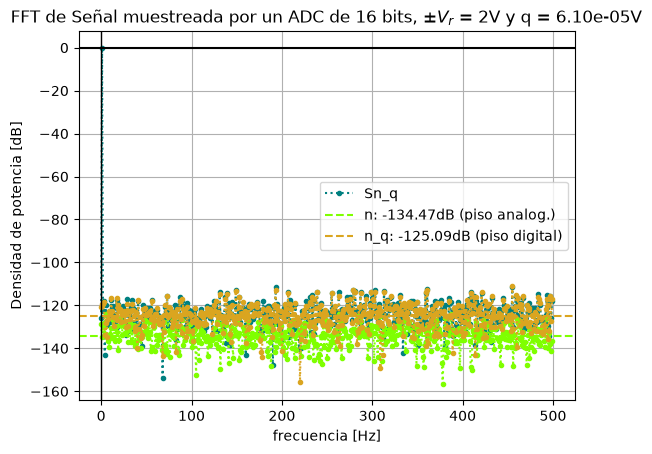

In [12]:
fftsn_abs, freq=funcion_fft(sn)
ref = np.max(fftsn_abs)
sn_fft_dB = 20 * np.log10(fftsn_abs/ref)

fftsn_cuant_abs, freq=funcion_fft(sn_cuantizada)
sn_cuant_fft_dB = 20 * np.log10(fftsn_cuant_abs/ref)

fftnorm_abs, freq=funcion_fft(norm)
norm_fft_dB = 20 * np.log10(fftnorm_abs/ref)

#Ruido de cuantización
n_q = sn_cuantizada - sn
fftn_q_abs, freq=funcion_fft(n_q)
n_q_fft_dB = 20 * np.log10(fftn_q_abs/ref)

plt.figure(5)
plt.plot(freq,sn_cuant_fft_dB,":.", color="teal",label="Sn_q")
plt.plot(freq,norm_fft_dB,":.", color="chartreuse")
plt.axhline(np.mean(norm_fft_dB), color="chartreuse", linestyle="--", label=f"n: {np.mean(norm_fft_dB):.2f}dB (piso analog.)")
plt.plot(freq,n_q_fft_dB,":.", color="goldenrod")
plt.axhline(np.mean(n_q_fft_dB), color="goldenrod", linestyle='--', label=f"n_q: {np.mean(n_q_fft_dB):.2f}dB (piso digital)")

plt.legend()
plt.title(f"FFT de Señal muestreada por un ADC de {bits} bits, ±$V_r$ = {Vfs}V y q = {q:.2e}V")
plt.ylabel("Densidad de potencia [dB]")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)

En esta situación, vemos nuevamente cómo *Sn_q* cuenta con un valor máximo igualado a 0 por el comportamiento de la sinusoidal. También, a diferencia del gráfico de densidad de potencia previo, las potencias medias de la normal y del ruido de cuantización difieren. La potencia de entrada (piso analógico) es menor que la potencia de salida (piso digital). Esto parte de una de las primeras fórmulas mencionadas: 
\begin{equation}
P_n=k_n*P_q \Longrightarrow P_n=\frac{P_q}{10}
\end{equation}
Empleando las propiedades del $log_{10}$ para hacer una conversión a dB, se genera esa diferencia aproximada de 10 decibeles entre las potencias. 

Por otro lado, observando la primer figura de densidad de potencia, es evidente cómo los bits empleados provocaron que la potencia media varíe tanto. Anteriormente, la potencia se encontraba $\approx-52dB$, mucho mayor que los valores actuales en dB, ya que P_q $>$ P_q2.

Text(0, 0.5, 'Nro de muestras')

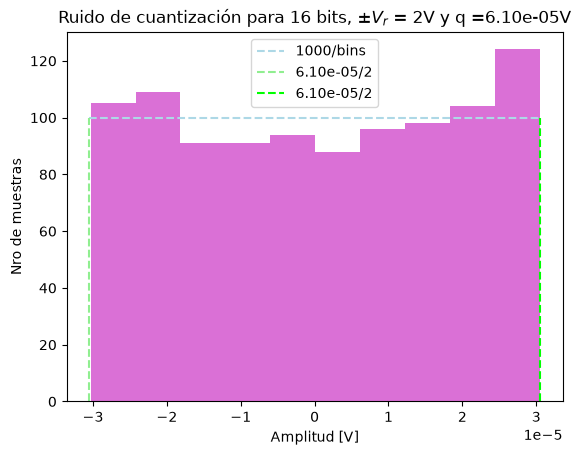

In [13]:
plt.figure (6)
plt.hist(n_q, color="orchid")
plt.hlines(100, xmin=-q/2, xmax=q/2,color="lightblue", linestyle="--", label=f"{N}/bins")
plt.vlines(-q/2, ymin=0, ymax=100, color="lightgreen", linestyle="--", label=f"{q:.2e}/2")
plt.vlines(q/2,ymin=0, ymax=100, color="lime", linestyle="--", label=f"{q:.2e}/2")
plt.title(f"Ruido de cuantización para {bits} bits, ±$V_r$ = {Vfs}V y q ={q:.2e}V")
plt.legend()
plt.xlabel("Amplitud [V]")
plt.ylabel("Nro de muestras")

Para la última figura, realizamos nuevamente un histograma sobre el número de muestras en relación a la amplitud, con valores máximos $\pm\frac{q}{2}$. Nótese la magnitud del eje de abscisas, cuya leyenda indica que se encuentra en el orden de los $10^{-5V}$. Una vez más, el histograma aparenta demostrar una distribucción uniforme entre amplitudes y muestras.

#### Bonus

Se buscará encontrar la relación entre el número de bits y el SNR de las señales digitalizadas.
Por los cálculos realizados en el código, sabemos que:
\begin{equation}
q=\frac{2*Vfs}{2^N} \wedge P_n=\frac{q^2}{12} \Longrightarrow P_n=\frac{(2*Vfs)^2}{12*2^{2N}}
\end{equation}

\begin{equation}
SNR=10*log_{10}(\frac{\sigma_q^2*12*2^{2N}}{(2*Vfs)^2})=10*log_{10}(12)+20*N*log_{10}(2)+20*log_{10}(\frac{\sigma_q}{2Vfs})
\end{equation}

\begin{equation}
SNR\approx 10,79 + 6,02*N+20*log_{10}(\frac{\sigma_q}{2Vfs})
\end{equation}


In [19]:
print(10.79+6.02*4+20*np.log((np.sqrt(P_q))/(2*Vfs)))

-45.43084094267564


In [22]:
print(10.79+6.02*16+20*np.log((np.sqrt(P_q2))/(2*Vfs)))

-139.54616427706253


Así, estos valores se asemejan (más o menos) a las potencias medias medidas previamente.

#### Conclusiones

Como resultado de este trabajo práctico, se apreciaron las diferencias generadas al cambiar dos simples parámetros, *B* y $k_n$. Estos provocaban que las señales cuantizadas sean más o menos precisas y que la potencia media de entrada y salida varíen.

A lo largo del códiigo además, se tuvieron que modificar detalles con respecto al ploteo, debido a cómo se superponían ciertas señales debido a la gran precisión (por los bits) o porque se mantenía la misma potencia media deseada (por el $k_n$).